# CSI multi-task model v1.1 — hrc_ur10_cell (Stage 2)

Train a small network to read one static CSI snapshot and predict
**presence / count / safety-zone** for the UR10 cell, as an
**experiment sweep**: one run per config, all results collected into a
single comparison table (so you don't re-run by hand and the comparisons
are apples-to-apples).

**Model** — the verified Stage-1 tiny ResNet (~406k params); shared neck; four
heads: presence (binary), count (0/1/2), zone (4-class, `clf` mode) and a
distance scalar (`dist` mode).

**L3 physics hybrid.** With `hybrid=True`, a short vector of **hand-computed
physics features** is concatenated to the CNN features before the neck: per-link
**log-energy** (which links the disturbance moved), per-link **delay centroid**
(how far the echo travelled), and a coarse **angle-of-arrival**. This is the
next rung of the physics-integration ladder above the physics *representations*
(`delay` / `delayangle`): instead of only reshaping the input, we hand the model
signal-processing cues it would otherwise have to rediscover. `hybrid=False`
reproduces the v0 model exactly.

**New in v1.1:**
- **Clean L3 isolation** — `delayangle_fix` (best rep + safety fix, *no* hybrid)
  is the baseline `hybrid_best` is measured against, so the effect of the
  physics features is finally isolated (it was confounded with the safety fix in
  v1).
- **Generalisation test** — `hybrid_best_gen` / `delayangle_fix_gen` repeat the
  pair on the `clutter_holdout` split (train ≤2 AGVs / test =3), asking whether
  L3 helps **transfer** — where physics is expected to pay off most.
- **Learning curve on the chosen model** — the curve now trains `hybrid_best`
  (not a throwaway baseline), and its full-size point **is** the saved model, so
  it is trained once, not re-run separately at the end.

**Each run is one config** in `EXPERIMENTS` (CONFIG cell). Axes: `input`
(`bgsub`/`raw`), `rep` (`complex`/`delay`/`delayangle`), `zone_mode`
(`dist`/`clf`), `split_mode` (`stored`/`clutter_holdout`), `hybrid`.

Results land in `results_df` + `results_experiments.csv`; per-run checkpoints
are saved as `csi_multitask_<name>.pt`.

> **GPU, fresh runtime.** Each run trains a fresh model. On Colab use a fresh
> runtime (Sionna's numpy pin breaks stock torch); on the lab machine run from
> the Sionna-free `.venv-model` GPU env. The setup cell auto-loads the
> dynamic-clutter dataset if present, else the Scene 1 anchor.

In [1]:
# ================================================================
# SETUP + FILE LOCATION
# Runs UNCHANGED on both Colab and the school lab machine.
#   - Colab : upload the notebook + .npz into /content
#   - Lab   : keep the notebook + .npz in the same folder
# torch + sklearn + pandas are preinstalled on Colab; on the lab
# machine they come from the global Python 3.14 pip install.
# ================================================================
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (balanced_accuracy_score, f1_score,
                             confusion_matrix, recall_score)

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False
IN_COLAB = _in_colab()

# Prefer the dynamic-clutter dataset if present, else the Scene 1 anchor.
DATA_CANDIDATES = ['hrc_ur10_dynamic_clutter_v0.npz',
                   'hrc_ur10_cell_data_v0_robot.npz']

# Search roots in priority order. Direct hit first (fast), then a
# recursive search as a fallback -- so it "just works" wherever the
# file sits, without editing paths per machine.
_roots = []
if IN_COLAB:
    _roots.append(Path('/content'))
_roots.append(Path.cwd())                                  # notebook's own folder
_roots.append(Path(r'C:/Users/u5737297/Documents/wifi sensing'))  # lab default (ignored if absent)

def _find(name, roots):
    seen = set()
    for r in roots:
        if (not r) or (r in seen) or (not r.exists()):
            continue
        seen.add(r)
        direct = r / name
        if direct.exists():
            return direct
        hit = next(iter(r.rglob(name)), None)   # recursive fallback
        if hit:
            return hit
    return None

NPZ_PATH = None
for _name in DATA_CANDIDATES:
    _hit = _find(_name, _roots)
    if _hit is not None:
        NPZ_PATH = str(_hit); DATA_NAME = _name; break
if NPZ_PATH is None:
    _searched = '\n  '.join(str(r) for r in _roots)
    raise FileNotFoundError(
        'No dataset found (' + ' or '.join(DATA_CANDIDATES) + '). Put one beside '
        f'this notebook (lab) or upload to /content (Colab). Searched:\n  {_searched}')

BASE_DIR = str(Path(NPZ_PATH).parent)   # outputs (the .pt checkpoint) saved here

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('env  :', 'Colab' if IN_COLAB else 'local/lab', '| torch', torch.__version__, '| device', DEVICE)
print('data :', NPZ_PATH)
print('out  :', BASE_DIR)

env  : local/lab | torch 2.11.0+cu128 | device cuda
data : c:\Users\u5737297\Documents\wifi sensing\stage2\hrc_ur10_dynamic_clutter_v0.npz
out  : c:\Users\u5737297\Documents\wifi sensing\stage2


## Data understanding (before modelling)

The data is simulated, but it still pays to look at it before training. These
three cells check the basics only:

1. **What is in the file** — the arrays the npz holds, plus a **per-sample
   pandas DataFrame** (`df`) of the labels and metadata (one row per snapshot:
   presence, count, zone, split, worker positions, and cheap per-sample
   magnitude summaries).
2. **Label balance** — how presence / count / zone are distributed, overall
   and across the train/val/test split (imbalance is why we use balanced
   accuracy and class weights later).
3. **Is the worker visible in the CSI** — the mean background-subtracted
   magnitude should be ~0 with nobody present and grow as workers are added,
   confirming the signal we want to sense is actually there.

**Storage note.** The dataset stays in the `.npz` (efficient, lossless, and
the only sensible home for the 4-D **complex** CSI tensor — pandas/CSV can't
hold that). We keep the CSI as **numpy** for the model, and derive the
**pandas** `df` from the same npz at load time for the tabular labels/metadata.
Nothing new is written to disk. Nothing here trains or changes the model — it
is a sanity check on the input. The cells use `df` and `*0` variables, so they
do not interfere with the modelling pipeline below.

In [2]:
# ================================================================
# DATA UNDERSTANDING (1/3) -- what is in the file + build the
# per-sample DataFrame (labels/metadata in pandas; CSI stays numpy)
# ================================================================
z0 = np.load(NPZ_PATH, allow_pickle=True)

# what the npz holds, as a small table
inv = pd.DataFrame([(k, str(z0[k].shape), str(z0[k].dtype)) for k in z0.files],
                   columns=['array', 'shape', 'dtype'])
print('npz contents:')
print(inv.to_string(index=False))

# CSI tensor stays numpy: 4-D complex -> not a DataFrame (see note below)
csi0 = z0['csi_bgsub']
N, M_AP, K_TX, N_SUB = csi0.shape
print(f'\nCSI tensor [N, M_AP, K_TX, N_sub] = [{N}, {M_AP}, {K_TX}, {N_SUB}], '
      f'{csi0.dtype}  -> kept as numpy for the model')
print('NaNs -> csi_raw:', int(np.isnan(z0['csi_raw']).sum()),
      '| csi_bgsub:', int(np.isnan(csi0).sum()))

# per-sample labels + metadata -> one row per snapshot
zone_labels = [str(s) for s in z0['zone_labels']]      # ['none','green','yellow','red']
pos = z0['positions']                                  # [N, 2 workers, 2 coords (x,y)]
df = pd.DataFrame({
    'presence': z0['presence'].astype(int),
    'count':    z0['count'].astype(int),
    'zone':     z0['zone'].astype(int),
    'split':    pd.Categorical(z0['split'].astype(str),
                               categories=['train', 'val', 'test']),
})
df['zone_name'] = pd.Categorical.from_codes(df['zone'], categories=zone_labels)
df['worker0_x'], df['worker0_y'] = pos[:, 0, 0], pos[:, 0, 1]
df['worker1_x'], df['worker1_y'] = pos[:, 1, 0], pos[:, 1, 1]
if 'agv_count' in z0.files:                            # dynamic-clutter dataset
    df['agv_count'] = z0['agv_count'].astype(int)
# cheap per-sample signal summaries (mean magnitude over antennas x subcarriers)
df['mean_abs_raw']   = np.abs(z0['csi_raw']).mean(axis=(1, 2, 3))
df['mean_abs_bgsub'] = np.abs(z0['csi_bgsub']).mean(axis=(1, 2, 3))

print(f'\nper-sample DataFrame: {df.shape[0]} rows x {df.shape[1]} cols'
      + ('  (with AGV clutter)' if 'agv_count' in df else '  (anchor, no clutter)'))
df.head()

npz contents:
                array            shape     dtype
              csi_raw (8000, 4, 4, 64) complex64
            csi_bgsub (8000, 4, 4, 64) complex64
            csi_empty       (4, 4, 64) complex64
                count          (8000,)      int8
             presence          (8000,)      int8
                 zone          (8000,)      int8
            positions     (8000, 2, 2)   float32
            agv_count          (8000,)      int8
        agv_positions     (8000, 3, 2)   float32
                split          (8000,)       <U5
              freq_hz               ()   float64
      num_subcarriers               ()     int64
subcarrier_spacing_hz               ()   float64
                 k_tx               ()     int64
                 m_ap               ()     int64
              human_z               ()   float64
          human_scale               ()   float64
              variant               ()       <U5
             agv_size             (3,)   float32
      

,presence,count,zone,split,zone_name,worker0_x,worker0_y,worker1_x,worker1_y,agv_count,mean_abs_raw,mean_abs_bgsub
0,1,2,1,test,green,3.327312,-0.426031,-4.609941,2.57767,3,0.944305,0.106946
1,1,1,3,train,red,1.395072,-0.515214,NaN,NaN,0,0.943225,0.011422
2,1,1,3,val,red,-0.519646,-0.651210,NaN,NaN,3,0.944024,0.051355
3,0,0,0,train,none,NaN,NaN,NaN,NaN,3,0.942733,0.040227
4,0,0,0,test,none,NaN,NaN,NaN,NaN,3,0.942767,0.025487


overall label balance:
  presence : {0: 2656, 1: 5344}
  count    : {0: 2656, 1: 2689, 2: 2655}
  zone     : {'none': 2656, 'green': 2993, 'yellow': 1366, 'red': 985}

zone x split (counts):
split      train  val  test
zone_name                  
none        1860  398   398
green       2075  465   453
yellow       973  187   206
red          694  149   142


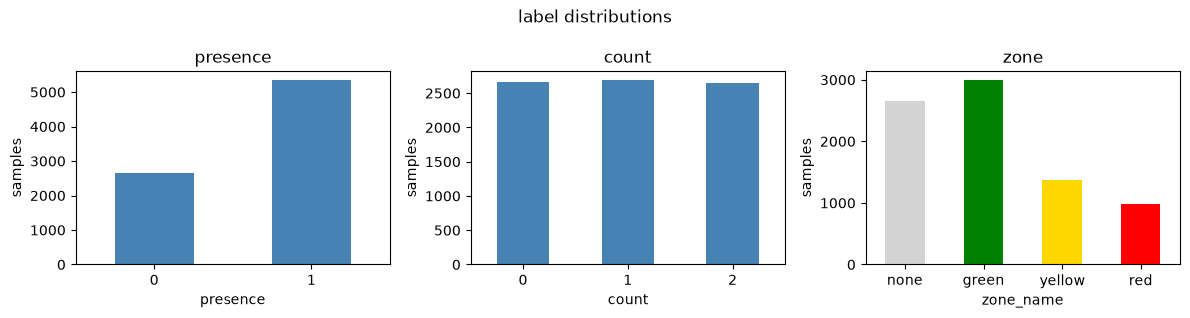

In [3]:
# ================================================================
# DATA UNDERSTANDING (2/3) -- label balance (pandas)
# ================================================================
print('overall label balance:')
print('  presence :', df['presence'].value_counts().sort_index().to_dict())
print('  count    :', df['count'].value_counts().sort_index().to_dict())
print('  zone     :', df['zone_name'].value_counts()[zone_labels].to_dict())

print('\nzone x split (counts):')
print(pd.crosstab(df['zone_name'], df['split']))

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
df['presence'].value_counts().sort_index().plot.bar(
    ax=ax[0], color='steelblue', title='presence', rot=0)
df['count'].value_counts().sort_index().plot.bar(
    ax=ax[1], color='steelblue', title='count', rot=0)
df['zone_name'].value_counts()[zone_labels].plot.bar(
    ax=ax[2], color=['lightgray', 'green', 'gold', 'red'], title='zone', rot=0)
for a in ax:
    a.set_ylabel('samples')
fig.suptitle('label distributions'); fig.tight_layout(); plt.show()

mean background-subtracted magnitude by worker count:
           mean       std  size
count                          
0      0.015692  0.020868  2656
1      0.049809  0.046895  2689
2      0.076977  0.057568  2655

overall  mean |csi_raw|   = 0.9435
overall  mean |csi_bgsub| = 0.0475

mean |csi_bgsub| by (human count x agv count):
agv_count      0      1      2      3
count                                
0          0.000  0.011  0.021  0.031
1          0.040  0.047  0.056  0.058
2          0.069  0.074  0.079  0.085


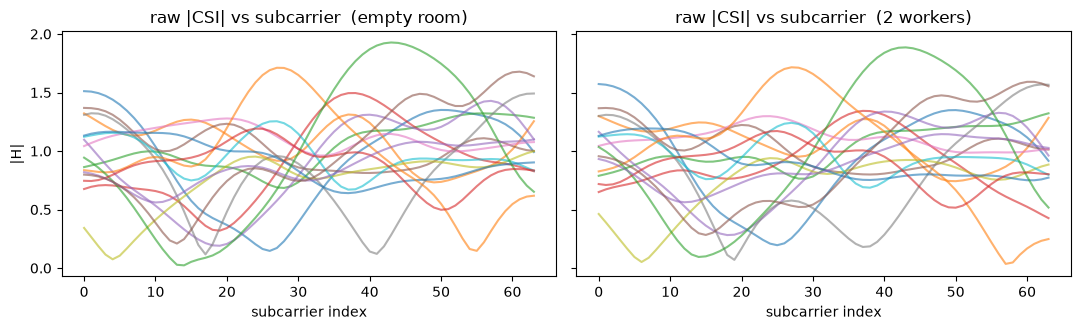

In [4]:
# ================================================================
# DATA UNDERSTANDING (3/3) -- is the worker visible in the CSI?
# Background subtraction removes the empty room, so |csi_bgsub|
# should be ~0 with nobody there and grow as workers are added.
# ================================================================
sig = df.groupby('count')['mean_abs_bgsub'].agg(['mean', 'std', 'size'])
print('mean background-subtracted magnitude by worker count:')
print(sig)
print('\noverall  mean |csi_raw|   =', round(float(df['mean_abs_raw'].mean()), 4))
print('overall  mean |csi_bgsub| =', round(float(df['mean_abs_bgsub'].mean()), 4))

# with clutter, condition on (human count x agv count): count-0 rows are no
# longer ~0 -- the AGV perturbation is the confound the model must see past.
if 'agv_count' in df:
    print('\nmean |csi_bgsub| by (human count x agv count):')
    print(df.pivot_table(index='count', columns='agv_count',
                         values='mean_abs_bgsub', aggfunc='mean').round(3))

# one empty vs one occupied snapshot: raw amplitude across subcarriers (from the tensor)
i_empty  = int(df.index[df['count'] == 0][0])
i_worker = int(df.index[df['count'] == 2][0])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for a, (ttl, idx) in zip(ax, [('empty room', i_empty), ('2 workers', i_worker)]):
    amp = np.abs(z0['csi_raw'][idx]).reshape(M_AP * K_TX, N_SUB)   # 16 links x 64 subcarriers
    a.plot(amp.T, alpha=0.6)
    a.set_title(f'raw |CSI| vs subcarrier  ({ttl})')
    a.set_xlabel('subcarrier index')
ax[0].set_ylabel('|H|')
fig.tight_layout(); plt.show()

In [5]:
# ================================================================
# CONFIG -- shared hyperparameters + the EXPERIMENT SWEEP (v1.1)
# ================================================================
# shared across every run
BATCH = 128
EPOCHS = 120
LR = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT_P = 0.2
SUBCARRIER_DROPOUT = 0.1
LAMBDA_DIST = 1.0         # default weight of the distance-regression loss (dist mode)
RED_SAFETY_MARGIN = 0.0   # default red-threshold margin (m); per-run 'red_margin' overrides

STEM_CH = 32
STAGE_CH = [32, 64, 96, 96]
STAGE_DS = [False, True, True, True]
N_COUNT, N_ZONE = 3, 4
ZONE_NAMES = ['none', 'green', 'yellow', 'red']

# Per-run keys (defaults in brackets):
#   input('bgsub') | rep('complex') | zone_mode('dist') | split_mode('stored')
#   red_margin(0.0) | dist_weighted(False) | hybrid(False) | phys_angle(True)
#
# v1.1 adds the CLEAN L3 ISOLATION the earlier sweep was missing:
#   * delayangle_fix = the best rep + safety fix but NO hybrid, so
#     hybrid_best vs delayangle_fix finally isolates the physics features.
#   * the *_gen pair repeats both on the clutter_holdout split -> does L3 help
#     GENERALISATION (a 2x2 of hybrid x split on the best config)?
# NOTE: hybrid_best is NOT listed here -- it is trained ONCE as the full-size
# point of the learning curve (LC_CFG below) and reused for the table + DETAIL,
# so it is never trained twice.
EXPERIMENTS = [
    # -- safety-fix comparison (vary the zone head; complex rep) --
    dict(name='dist_base',     input='bgsub', rep='complex', zone_mode='dist', split_mode='stored'),
    dict(name='dist_margin',   input='bgsub', rep='complex', zone_mode='dist', split_mode='stored', red_margin=0.4),
    dict(name='dist_weighted', input='bgsub', rep='complex', zone_mode='dist', split_mode='stored', dist_weighted=True),
    dict(name='dist_both',     input='bgsub', rep='complex', zone_mode='dist', split_mode='stored', red_margin=0.4, dist_weighted=True),
    dict(name='zone_clf',      input='bgsub', rep='complex', zone_mode='clf',  split_mode='stored'),
    # -- representation ablation --
    dict(name='delay',         input='bgsub', rep='delay',      zone_mode='dist', split_mode='stored'),
    dict(name='delayangle',    input='bgsub', rep='delayangle', zone_mode='dist', split_mode='stored'),
    # -- L3 isolation on the plain rep --
    dict(name='hybrid_complex', input='bgsub', rep='complex',   zone_mode='dist', split_mode='stored', hybrid=True),
    # -- L3 isolation + GENERALISATION on the best config (2x2 hybrid x split);
    #    hybrid_best (stored, hybrid) itself comes from the learning curve --
    dict(name='delayangle_fix',     input='bgsub', rep='delayangle', zone_mode='dist', split_mode='stored',          red_margin=0.4, dist_weighted=True),
    dict(name='hybrid_best_gen',    input='bgsub', rep='delayangle', zone_mode='dist', split_mode='clutter_holdout', red_margin=0.4, dist_weighted=True, hybrid=True),
    dict(name='delayangle_fix_gen', input='bgsub', rep='delayangle', zone_mode='dist', split_mode='clutter_holdout', red_margin=0.4, dist_weighted=True),
]

# The CHOSEN config -- trained as a learning curve; its full-size point is the
# saved hybrid_best model AND the top of the curve (trained ONCE, not twice).
LC_CFG = dict(name='hybrid_best', input='bgsub', rep='delayangle', zone_mode='dist',
              split_mode='stored', red_margin=0.4, dist_weighted=True, hybrid=True)
LC_NAME = 'hybrid_best'
LC_SIZES = [1000, 2000, 3500]     # sub-full points; the full training set is appended in the sweep

DETAIL_NAME = 'hybrid_best'   # detailed plots for the chosen model (from the LC full-size point)
torch.manual_seed(0); np.random.seed(0)
print(f'{len(EXPERIMENTS)} sweep configs + a learning curve on {LC_NAME}')
print('sweep:', [e['name'] for e in EXPERIMENTS])

11 sweep configs + a learning curve on hybrid_best
sweep: ['dist_base', 'dist_margin', 'dist_weighted', 'dist_both', 'zone_clf', 'delay', 'delayangle', 'hybrid_complex', 'delayangle_fix', 'hybrid_best_gen', 'delayangle_fix_gen']


In [6]:
# ================================================================
# DATA: load once; build_data(cfg) applies the representation + split
# per config (CSI stays numpy; distance target for the ordinal head).
# v1: also builds the L3 HYBRID physics-feature vector when cfg['hybrid'].
# ================================================================
z = np.load(NPZ_PATH, allow_pickle=True)
_HAS_AGV = 'agv_count' in z.files
print('dataset:', DATA_NAME, '| has AGV clutter:', _HAS_AGV)

def representation(c, rep):
    # complex [N,M_AP,K_TX,N_sub] -> real [N, 2*K_TX, M_AP, N_sub]
    if rep == 'complex':      t = c                                  # frequency domain
    elif rep == 'delay':      t = np.fft.ifft(c, axis=-1)            # -> delay domain
    elif rep == 'delayangle': t = np.fft.ifft(np.fft.fft(c, axis=1), axis=-1)  # angle x delay
    else: raise ValueError(f'unknown rep={rep}')
    s = np.stack([t.real, t.imag], axis=1)          # [N,2,M_AP,K_TX,N_sub]
    s = np.transpose(s, (0, 1, 3, 2, 4))            # [N,2,K_TX,M_AP,N_sub]
    return s.reshape(c.shape[0], 2*c.shape[2], c.shape[1], c.shape[3]).astype(np.float32)

def physics_features(c, use_angle=True):
    # L3 HYBRID -- hand-computed physics cues per snapshot, from the complex
    # (background-subtracted) CSI c [N, M_AP, K_TX, N_sub]. Returns [N, phys_dim].
    # These are signal-processing steps we would otherwise hope the CNN
    # rediscovers; handing them over is the "add physics to the model" rung.
    N = c.shape[0]
    # (1) per-link log-energy -- WHICH links the disturbance moved (fingerprint)
    energy = (np.abs(c) ** 2).sum(axis=-1).reshape(N, -1)                 # [N,16]
    log_energy = np.log(energy + 1e-8).astype(np.float32)
    # (2) per-link delay centroid -- HOW FAR the echo travelled (sub-bin range)
    cir = np.abs(np.fft.ifft(c, axis=-1))                                # [N,M_AP,K_TX,N_sub] delay domain
    taps = np.arange(c.shape[-1])
    centroid = (cir * taps).sum(-1) / (cir.sum(-1) + 1e-8)               # [N,M_AP,K_TX]
    centroid = (centroid / c.shape[-1]).reshape(N, -1).astype(np.float32)  # normalized [N,16]
    feats = [log_energy, centroid]
    # (3) optional coarse angle-of-arrival per TX from the AP array (4 antennas)
    if use_angle:
        ang = np.abs(np.fft.fft(c, axis=1))                              # FFT over M_AP antennas
        doa = (ang.sum(-1).argmax(axis=1) / c.shape[1]).astype(np.float32)  # [N,K_TX] peak-dir per TX
        feats.append(doa)
    return np.concatenate(feats, axis=1).astype(np.float32)              # [N, phys_dim]

def build_data(cfg):
    csi = z['csi_bgsub'] if cfg['input'] == 'bgsub' else z['csi_raw']
    presence = z['presence'].astype(np.int64); count = z['count'].astype(np.int64)
    zone = z['zone'].astype(np.int64); split = z['split'].astype(str)
    agv = (z['agv_count'].astype(np.int64) if _HAS_AGV else np.zeros(len(count), np.int64))
    N = len(count)
    ZCENTER = np.asarray(z['zone_center'], np.float32)
    RED_R = float(z['red_radius']); YEL_R = float(z['yellow_radius'])
    X = representation(csi, cfg['rep'])
    # split
    if cfg['split_mode'] == 'clutter_holdout' and (agv > 2).any():
        te = agv >= 3; _tv = agv <= 2
        _rs = np.random.default_rng(0); _idx = np.where(_tv)[0]; _rs.shuffle(_idx)
        va = np.zeros(N, bool); va[_idx[:int(0.15*len(_idx))]] = True; tr = _tv & ~va
    else:
        tr, va, te = split == 'train', split == 'val', split == 'test'
    # optional: subsample the TRAIN set (learning curve); val/test unchanged
    _tn = cfg.get('train_n')
    if _tn is not None and _tn < int(tr.sum()):
        _keep = np.random.default_rng(123).choice(np.where(tr)[0], size=_tn, replace=False)
        tr = np.zeros(N, bool); tr[_keep] = True
    # standardize CSI on train only
    xm = X[tr].mean(axis=(0, 2, 3), keepdims=True); xs = X[tr].std(axis=(0, 2, 3), keepdims=True) + 1e-6
    Xn = (X - xm) / xs
    # L3 hybrid physics features (from the SAME input CSI; most meaningful on
    # bgsub). phys_dim=0 when hybrid off -> the model is exactly v0.
    if cfg.get('hybrid', False):
        Xp = physics_features(csi, use_angle=cfg.get('phys_angle', True))
        pm = Xp[tr].mean(0, keepdims=True); ps = Xp[tr].std(0, keepdims=True) + 1e-6
        Xp = ((Xp - pm) / ps).astype(np.float32)                        # z-score on train only
    else:
        Xp = np.zeros((N, 0), np.float32); pm = ps = None
    # nearest-human distance-to-robot (dist zone target); NaN->0, masked by presence
    pos = z['positions']; _d = np.hypot(pos[..., 0] - ZCENTER[0], pos[..., 1] - ZCENTER[1])
    _d = np.where(np.isnan(_d), np.inf, _d).min(axis=1)
    dist_fill = np.nan_to_num(np.where(count > 0, _d, np.nan), nan=0.0).astype(np.float32)
    return dict(Xn=Xn, Xp=Xp, phys_dim=int(Xp.shape[1]), presence=presence, count=count,
                zone=zone, agv=agv, tr=tr, va=va, te=te, dist_fill=dist_fill,
                x_mean=xm, x_std=xs, phys_mean=pm, phys_std=ps, RED_R=RED_R, YEL_R=YEL_R)

print('build_data ready | reps: complex / delay / delayangle | + L3 physics features (hybrid)')

dataset: hrc_ur10_dynamic_clutter_v0.npz | has AGV clutter: True
build_data ready | reps: complex / delay / delayangle | + L3 physics features (hybrid)


In [7]:
# ================================================================
# MODEL: Stage-1 tiny ResNet backbone + shared neck + 4 heads
#   presence (binary) | count (3) | zone (4, clf mode) | dist (1, dist mode)
# L3 HYBRID (v1): optional hand-computed physics features (phys_dim>0) are
#   concatenated to the pooled CNN features before the neck. phys_dim=0 ->
#   byte-for-byte the v0 model, so non-hybrid runs are unchanged.
# ================================================================
class BasicBlock(nn.Module):
    """ResNet basic block. Stride (1, s) downsamples ONLY the last (width) axis."""
    def __init__(self, cin, cout, stride_w=1):
        super().__init__()
        s = (1, stride_w)
        self.conv1 = nn.Conv2d(cin, cout, 3, stride=s, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.proj = None
        if cin != cout or stride_w != 1:
            self.proj = nn.Sequential(nn.Conv2d(cin, cout, 1, stride=s, bias=False),
                                      nn.BatchNorm2d(cout))
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        idt = x if self.proj is None else self.proj(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + idt)


class CSINetMulti(nn.Module):
    def __init__(self, in_ch=8, stem=STEM_CH, stage_ch=STAGE_CH, stage_ds=STAGE_DS,
                 p=DROPOUT_P, phys_dim=0):
        super().__init__()
        self.phys_dim = phys_dim
        self.stem = nn.Sequential(nn.Conv2d(in_ch, stem, 3, padding=1, bias=False),
                                  nn.BatchNorm2d(stem), nn.ReLU(inplace=True))
        blocks, c = [], stem
        for cout, ds in zip(stage_ch, stage_ds):
            blocks.append(BasicBlock(c, cout, stride_w=2 if ds else 1)); c = cout
        self.stages = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        # neck input = pooled CNN features (c) + hand-computed physics (phys_dim)
        self.neck = nn.Sequential(nn.Linear(c + phys_dim, 64), nn.ReLU(inplace=True), nn.Dropout(p))
        self.head_presence = nn.Linear(64, 1)
        self.head_count = nn.Linear(64, N_COUNT)
        self.head_zone = nn.Linear(64, N_ZONE)   # ZONE_MODE='clf'
        self.head_dist = nn.Linear(64, 1)        # ZONE_MODE='dist' (metres)

    def forward(self, x, phys=None):
        f = self.pool(self.stages(self.stem(x))).flatten(1)   # [B, c] learned features
        if self.phys_dim:
            f = torch.cat([f, phys], dim=1)                   # + hand-computed physics
        f = self.neck(f)
        return (self.head_presence(f).squeeze(1), self.head_count(f),
                self.head_zone(f), self.head_dist(f).squeeze(1))

print(f'model params (no physics)  : {sum(p.numel() for p in CSINetMulti().parameters()):,}')
print(f'model params (phys_dim=36) : {sum(p.numel() for p in CSINetMulti(phys_dim=36).parameters()):,}')

model params (no physics)  : 406,089
model params (phys_dim=36) : 408,393


In [8]:
# ================================================================
# run_experiment(cfg) -- build data, train a fresh model, evaluate.
# Returns a metrics ROW + a DETAIL dict (predictions + history) and
# saves a per-run checkpoint (unless cfg['no_save']). Reused by the sweep.
# v1: threads the L3 physics-feature vector (b['Xp']) through the loaders
#     and into model(x, phys); phys_dim=0 -> identical to v0.
# ================================================================
def run_experiment(cfg):
    b = build_data(cfg); RED_R, YEL_R = b['RED_R'], b['YEL_R']; zm = cfg['zone_mode']
    RED_M = cfg.get('red_margin', RED_SAFETY_MARGIN)     # per-run red decision margin
    LAM   = cfg.get('lambda_dist', LAMBDA_DIST)
    DISTW = cfg.get('dist_weighted', False)              # weight distance loss by zone rarity

    def loader(m, sh):
        ds = TensorDataset(torch.tensor(b['Xn'][m]), torch.tensor(b['Xp'][m]),
                           torch.tensor(b['presence'][m]), torch.tensor(b['count'][m]),
                           torch.tensor(b['zone'][m]), torch.tensor(b['dist_fill'][m]))
        return DataLoader(ds, batch_size=BATCH, shuffle=sh, drop_last=False)
    dl_tr, dl_va, dl_te = loader(b['tr'], True), loader(b['va'], False), loader(b['te'], False)

    zbal = np.bincount(b['zone'][b['tr']], minlength=N_ZONE).astype(np.float32)
    zw = (zbal.sum() / (N_ZONE * np.maximum(zbal, 1)))
    zone_w = torch.tensor(zw / zw.mean(), dtype=torch.float32, device=DEVICE)   # per-class, mean 1

    torch.manual_seed(0); np.random.seed(0)               # identical init per run
    model = CSINetMulti(phys_dim=b['phys_dim']).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    bce = nn.BCEWithLogitsLoss(); ce = nn.CrossEntropyLoss()
    ce_zone = nn.CrossEntropyLoss(weight=zone_w)
    huber = nn.SmoothL1Loss(); huber_n = nn.SmoothL1Loss(reduction='none')

    def sc_dropout(xb):
        if SUBCARRIER_DROPOUT <= 0: return xb
        keep = (torch.rand(xb.shape[-1], device=xb.device) > SUBCARRIER_DROPOUT).float()
        return xb * keep

    def zpred(pl, dd):                                    # dist -> zone rings, gated by presence
        pres = torch.sigmoid(pl) > 0.5
        zz = torch.where(dd <= YEL_R, torch.full_like(dd, 2.0), torch.ones_like(dd))
        zz = torch.where(dd <= RED_R + RED_M, torch.full_like(dd, 3.0), zz)   # widened by margin
        return torch.where(pres, zz, torch.zeros_like(dd)).long()

    @torch.no_grad()
    def evaluate(dl):
        model.eval(); P = {k: [] for k in ['p','c','z']}; T = {k: [] for k in ['p','c','z']}; da, dn = 0.0, 0
        for xb, xp, yp, yc, yz, yd in dl:
            pl, cl, zl, dd = model(xb.to(DEVICE), xp.to(DEVICE))
            P['p'].append((torch.sigmoid(pl) > 0.5).long().cpu()); T['p'].append(yp)
            P['c'].append(cl.argmax(1).cpu()); T['c'].append(yc)
            P['z'].append(zl.argmax(1).cpu() if zm == 'clf' else zpred(pl, dd).cpu()); T['z'].append(yz)
            m = yp > 0.5
            if m.any(): da += (dd.cpu()[m] - yd[m]).abs().sum().item(); dn += int(m.sum())
        P = {k: torch.cat(v).numpy() for k, v in P.items()}; T = {k: torch.cat(v).numpy() for k, v in T.items()}
        return P, T, {k: balanced_accuracy_score(T[k], P[k]) for k in P}, (da / dn if dn else float('nan'))

    best, best_state, hist = -1, None, []
    for ep in range(1, EPOCHS + 1):
        model.train(); run = 0.0
        for xb, xp, yp, yc, yz, yd in dl_tr:
            xb = sc_dropout(xb.to(DEVICE)); xp = xp.to(DEVICE)
            yp, yc, yz, yd = yp.float().to(DEVICE), yc.to(DEVICE), yz.to(DEVICE), yd.float().to(DEVICE)
            pl, cl, zl, dd = model(xb, xp); loss = bce(pl, yp) + ce(cl, yc)
            if zm == 'clf':
                loss = loss + ce_zone(zl, yz)
            else:
                m = yp > 0.5
                if m.any():
                    if DISTW:                             # up-weight rare (near/red) samples
                        w = zone_w[yz[m]]
                        dloss = (huber_n(dd[m], yd[m]) * w).sum() / w.sum()
                    else:
                        dloss = huber(dd[m], yd[m])
                    loss = loss + LAM * dloss
            opt.zero_grad(); loss.backward(); opt.step(); run += loss.item() * xb.size(0)
        sched.step()
        _, _, bacc, dmae = evaluate(dl_va); mb = float(np.mean(list(bacc.values())))
        hist.append((run / int(b['tr'].sum()), bacc['p'], bacc['c'], bacc['z'], dmae))
        if mb > best:
            best = mb; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)

    P, T, _, dmae = evaluate(dl_te); agv_te = b['agv'][b['te']]
    noh = T['p'] == 0; clut = noh & (agv_te >= 1)
    row = dict(name=cfg['name'], rep=cfg['rep'], zone=zm, split=cfg['split_mode'],
               hybrid=bool(b['phys_dim']), redMargin=RED_M, distW=DISTW, trainN=int(b['tr'].sum()),
               presAcc=(P['p'] == T['p']).mean(), countAcc=(P['c'] == T['c']).mean(),
               zoneAcc=(P['z'] == T['z']).mean(), zoneBAcc=balanced_accuracy_score(T['z'], P['z']),
               redRecall=(recall_score(T['z'] == 3, P['z'] == 3) if (T['z'] == 3).any() else np.nan),
               detProb=(recall_score(T['p'], P['p'], pos_label=1) if (T['p'] == 1).any() else np.nan),
               faClut=(float(P['p'][clut].mean()) if clut.any() else np.nan),
               distMAE=dmae, bestVal=best, nTest=int(b['te'].sum()))
    if not cfg.get('no_save'):
        ckpt = os.path.join(BASE_DIR, f"csi_multitask_{cfg['name']}.pt")
        torch.save({'state_dict': model.state_dict(), 'cfg': cfg, 'row': row,
                    'x_mean': b['x_mean'], 'x_std': b['x_std'],
                    'phys_mean': b['phys_mean'], 'phys_std': b['phys_std'],
                    'phys_dim': b['phys_dim'], 'red_r': RED_R, 'yel_r': YEL_R}, ckpt)
    return row, dict(P=P, T=T, agv_te=agv_te, hist=np.array(hist))

print('run_experiment ready')

run_experiment ready


In [9]:
# ================================================================
# SWEEP -- run every ablation config, THEN the LEARNING CURVE of the
# CHOSEN config (LC_CFG). The curve's FULL-size point is trained ONCE and
# reused as the saved hybrid_best model + its table row + DETAIL, so nothing
# is trained twice. Each run trains a fresh model -> use a GPU.
# ================================================================
_rows, DETAILS, lc_rows = [], {}, []
_t0 = time.time()

# (1) ablation / comparison sweep
for cfg in EXPERIMENTS:
    print(f"running {cfg['name']:18s} ...", end=' ', flush=True)
    _row, _det = run_experiment(cfg)
    _rows.append(_row); DETAILS[cfg['name']] = _det
    print(f"presAcc {_row['presAcc']:.3f} | countAcc {_row['countAcc']:.3f} | "
          f"zoneBAcc {_row['zoneBAcc']:.3f} | redRec {_row['redRecall']:.3f}")

# (2) learning curve of the CHOSEN config; the full-size point IS the saved model
_full_n = int(build_data(LC_CFG)['tr'].sum())
_sizes = [s for s in LC_SIZES if s < _full_n] + [_full_n]
print(f"\nlearning curve on {LC_NAME} (chosen config):")
for n in _sizes:
    _is_full = (n == _full_n)
    _name = LC_NAME if _is_full else f'lc_{n}'
    print(f"  train_n {n:>5} ...", end=' ', flush=True)
    _row, _det = run_experiment({**LC_CFG, 'train_n': n, 'no_save': not _is_full, 'name': _name})
    lc_rows.append(dict(train_n=int(_row['trainN']), presAcc=_row['presAcc'], countAcc=_row['countAcc'],
                        zoneBAcc=_row['zoneBAcc'], redRecall=_row['redRecall'],
                        faClut=_row['faClut'], distMAE=_row['distMAE']))
    if _is_full:                      # full-size model IS hybrid_best -> table + DETAIL
        _rows.append(_row); DETAILS[_name] = _det
    print(f"presAcc {_row['presAcc']:.3f} | zoneBAcc {_row['zoneBAcc']:.3f} | redRec {_row['redRecall']:.3f}")

results_df = pd.DataFrame(_rows).set_index('name')
lc_df = pd.DataFrame(lc_rows)
print(f"\nsweep + learning curve done in {(time.time()-_t0)/60:.1f} min")
results_df.round(3)

running dist_base          ... presAcc 0.918 | countAcc 0.667 | zoneBAcc 0.542 | redRec 0.345
running dist_margin        ... presAcc 0.914 | countAcc 0.673 | zoneBAcc 0.580 | redRec 0.563
running dist_weighted      ... presAcc 0.925 | countAcc 0.666 | zoneBAcc 0.553 | redRec 0.408
running dist_both          ... presAcc 0.922 | countAcc 0.664 | zoneBAcc 0.595 | redRec 0.592
running zone_clf           ... presAcc 0.916 | countAcc 0.678 | zoneBAcc 0.567 | redRec 0.507
running delay              ... presAcc 0.920 | countAcc 0.695 | zoneBAcc 0.560 | redRec 0.317
running delayangle         ... presAcc 0.937 | countAcc 0.691 | zoneBAcc 0.589 | redRec 0.458
running hybrid_complex     ... presAcc 0.912 | countAcc 0.696 | zoneBAcc 0.554 | redRec 0.373
running delayangle_fix     ... presAcc 0.931 | countAcc 0.690 | zoneBAcc 0.619 | redRec 0.669
running hybrid_best_gen    ... presAcc 0.869 | countAcc 0.654 | zoneBAcc 0.564 | redRec 0.593
running delayangle_fix_gen ... presAcc 0.850 | countAcc 0.62

,rep,zone,split,hybrid,redMargin,distW,trainN,presAcc,countAcc,zoneAcc,zoneBAcc,redRecall,detProb,faClut,distMAE,bestVal,nTest
name,,,,,,,,,,,,,,,,,
dist_base,complex,dist,stored,False,0.0,False,5602,0.918,0.667,0.605,0.542,0.345,0.926,0.137,0.945,0.710,1199
dist_margin,complex,dist,stored,False,0.4,False,5602,0.914,0.673,0.621,0.580,0.563,0.935,0.179,0.940,0.711,1199
dist_weighted,complex,dist,stored,False,0.0,True,5602,0.925,0.666,0.606,0.553,0.408,0.941,0.151,0.930,0.713,1199
dist_both,complex,dist,stored,False,0.4,True,5602,0.922,0.664,0.636,0.595,0.592,0.935,0.147,0.912,0.720,1199
zone_clf,complex,clf,stored,False,0.0,False,5602,0.916,0.678,0.661,0.567,0.507,0.931,0.161,2.323,0.713,1199
delay,delay,dist,stored,False,0.0,False,5602,0.920,0.695,0.639,0.560,0.317,0.930,0.140,0.863,0.750,1199
delayangle,delayangle,dist,stored,False,0.0,False,5602,0.937,0.691,0.625,0.589,0.458,0.938,0.091,0.900,0.741,1199
hybrid_complex,complex,dist,stored,True,0.0,False,5602,0.912,0.696,0.606,0.554,0.373,0.941,0.204,0.921,0.725,1199
delayangle_fix,delayangle,dist,stored,False,0.4,True,5602,0.931,0.690,0.647,0.619,0.669,0.946,0.140,0.878,0.749,1199


detailed view of run: hybrid_best


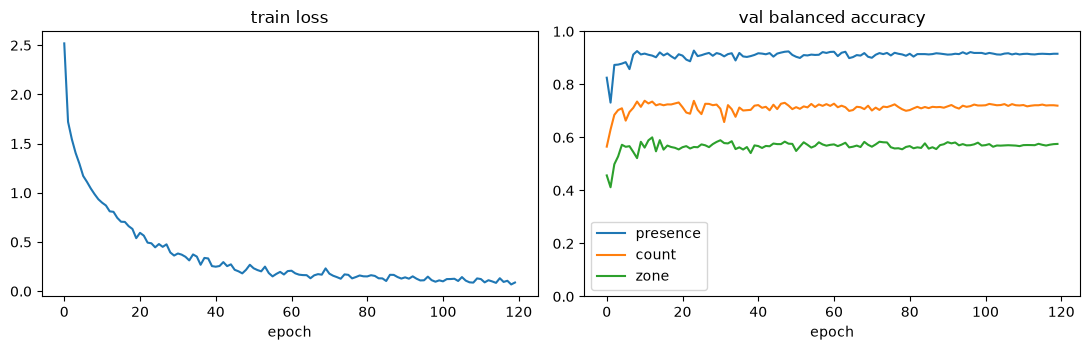

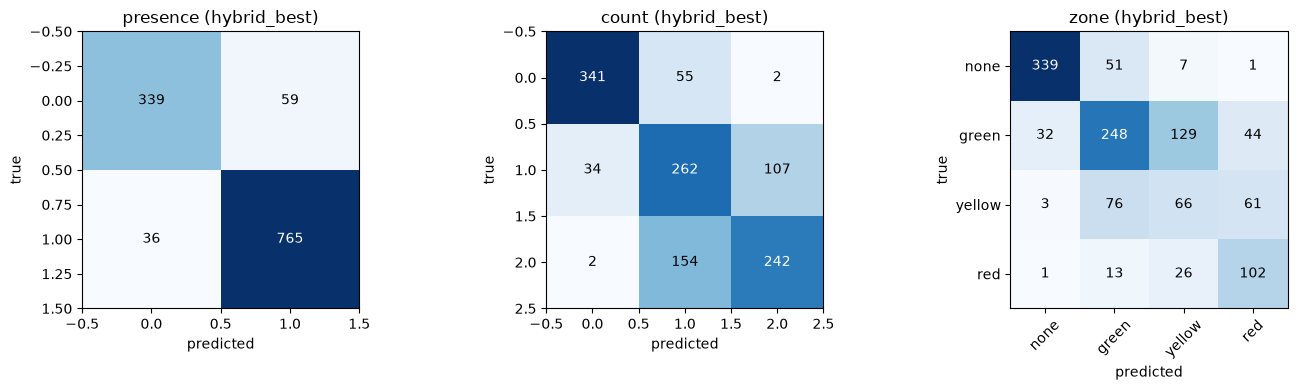

detection prob 0.955 | false-alarm (>=1 AGV) 0.207 | (0 AGV) 0.000
robustness vs #AGV:   #AGV     n   presAcc  countAcc  zoneBAcc  redRecall
          0    316    0.962     0.807     0.663     0.719
          1    308    0.951     0.705     0.626     0.641
          2    290    0.924     0.693     0.583     0.816
          3    285    0.839     0.604     0.567     0.697


In [10]:
# ================================================================
# DETAIL -- curves + confusion matrices + robustness for DETAIL_NAME
# ================================================================
d = DETAILS[DETAIL_NAME]; P, T, agv_te, hist = d['P'], d['T'], d['agv_te'], d['hist']
print('detailed view of run:', DETAIL_NAME)

# training curves
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(hist[:, 0]); ax[0].set_title('train loss'); ax[0].set_xlabel('epoch')
ax[1].plot(hist[:, 1], label='presence'); ax[1].plot(hist[:, 2], label='count'); ax[1].plot(hist[:, 3], label='zone')
ax[1].set_title('val balanced accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].set_ylim(0, 1)
fig.tight_layout(); plt.show()

# confusion matrices
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, (name, k) in zip(ax, [('presence', 'p'), ('count', 'c'), ('zone', 'z')]):
    cm = confusion_matrix(T[k], P[k]); a.imshow(cm, cmap='Blues'); a.set_title(f'{name} ({DETAIL_NAME})')
    a.set_xlabel('predicted'); a.set_ylabel('true')
    for (r, cc), v in np.ndenumerate(cm):
        a.text(cc, r, int(v), ha='center', va='center', color='white' if v > cm.max()/2 else 'black')
    if name == 'zone':
        a.set_xticks(range(4)); a.set_xticklabels(ZONE_NAMES, rotation=45)
        a.set_yticks(range(4)); a.set_yticklabels(ZONE_NAMES)
fig.tight_layout(); plt.show()

# detection vs false-alarm + robustness vs #AGV
noh = T['p'] == 0
print(f"detection prob {recall_score(T['p'], P['p'], pos_label=1):.3f} | "
      f"false-alarm (>=1 AGV) {float(P['p'][noh & (agv_te>=1)].mean()) if (noh&(agv_te>=1)).any() else float('nan'):.3f} | "
      f"(0 AGV) {float(P['p'][noh & (agv_te==0)].mean()) if (noh&(agv_te==0)).any() else float('nan'):.3f}")
if agv_te.max() > 0:
    print('robustness vs #AGV:   #AGV     n   presAcc  countAcc  zoneBAcc  redRecall')
    for ac in range(int(agv_te.max()) + 1):
        s = agv_te == ac
        if not s.any(): continue
        rr = recall_score(T['z'][s] == 3, P['z'][s] == 3) if (T['z'][s] == 3).any() else float('nan')
        print(f'   {ac:8d} {int(s.sum()):6d}    {(P["p"][s]==T["p"][s]).mean():.3f}     '
              f'{(P["c"][s]==T["c"][s]).mean():.3f}     {balanced_accuracy_score(T["z"][s], P["z"][s]):.3f}     {rr:.3f}')

In [11]:
# --- save the comparison table (per-run checkpoints already saved by run_experiment) ---
csv = os.path.join(BASE_DIR, 'results_experiments.csv')
results_df.to_csv(csv)
print('saved', csv)
print('per-run checkpoints: csi_multitask_<name>.pt in', BASE_DIR)
results_df.round(3)

saved c:\Users\u5737297\Documents\wifi sensing\stage2\results_experiments.csv
per-run checkpoints: csi_multitask_<name>.pt in c:\Users\u5737297\Documents\wifi sensing\stage2


,rep,zone,split,hybrid,redMargin,distW,trainN,presAcc,countAcc,zoneAcc,zoneBAcc,redRecall,detProb,faClut,distMAE,bestVal,nTest
name,,,,,,,,,,,,,,,,,
dist_base,complex,dist,stored,False,0.0,False,5602,0.918,0.667,0.605,0.542,0.345,0.926,0.137,0.945,0.710,1199
dist_margin,complex,dist,stored,False,0.4,False,5602,0.914,0.673,0.621,0.580,0.563,0.935,0.179,0.940,0.711,1199
dist_weighted,complex,dist,stored,False,0.0,True,5602,0.925,0.666,0.606,0.553,0.408,0.941,0.151,0.930,0.713,1199
dist_both,complex,dist,stored,False,0.4,True,5602,0.922,0.664,0.636,0.595,0.592,0.935,0.147,0.912,0.720,1199
zone_clf,complex,clf,stored,False,0.0,False,5602,0.916,0.678,0.661,0.567,0.507,0.931,0.161,2.323,0.713,1199
delay,delay,dist,stored,False,0.0,False,5602,0.920,0.695,0.639,0.560,0.317,0.930,0.140,0.863,0.750,1199
delayangle,delayangle,dist,stored,False,0.0,False,5602,0.937,0.691,0.625,0.589,0.458,0.938,0.091,0.900,0.741,1199
hybrid_complex,complex,dist,stored,True,0.0,False,5602,0.912,0.696,0.606,0.554,0.373,0.941,0.204,0.921,0.725,1199
delayangle_fix,delayangle,dist,stored,False,0.4,True,5602,0.931,0.690,0.647,0.619,0.669,0.946,0.140,0.878,0.749,1199


## Learning curve (of the chosen model)

This is the learning curve of the **chosen config** — `hybrid_best` (delayangle +
dist_both + physics) — **not** a throwaway baseline, so it tells us how the model
we actually keep scales with data. It was trained in the SWEEP cell above on
growing slices of the training split (1k, 2k, 3.5k, full), with validation and
test fixed. The **full-size point is the saved `hybrid_best` model** — trained
once and reused for the comparison table and the DETAIL plots — so nothing is
re-run at the end. This cell just plots the `lc_df` already collected above.

**How to read it:** if a curve is **still rising** at the full size, more data of
the same scene would help that metric → a bigger dynamic set is justified. If it
has **flattened**, 8k is enough and the ceiling is elsewhere (physics / static
snapshot / geometry). Watch **`zoneBAcc`** — that is the number in question for
the >0.8 target — alongside `distMAE` (the continuous skill) and `redRecall`
(noisy, rare class).

learning curve of hybrid_best
 train_n  presAcc  countAcc  zoneBAcc  redRecall  faClut  distMAE
    1000    0.884     0.648     0.525      0.458   0.211    1.021
    2000    0.918     0.686     0.538      0.711   0.133    1.067
    3500    0.915     0.686     0.589      0.648   0.130    0.912
    5602    0.921     0.705     0.609      0.718   0.207    0.844


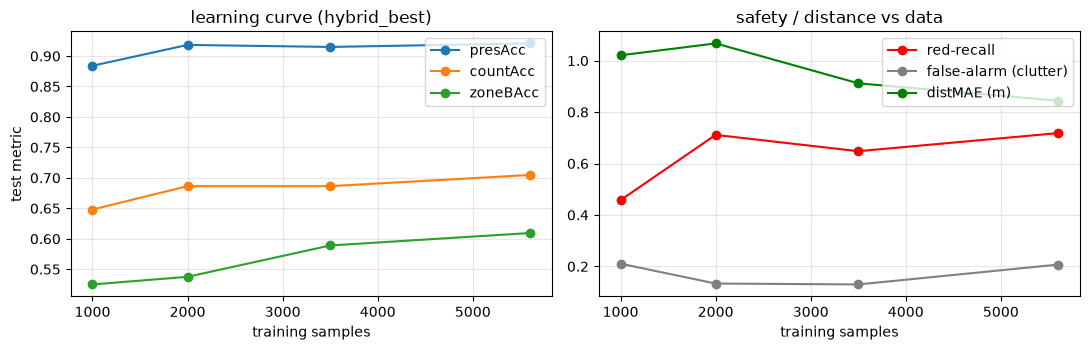

In [12]:
# ================================================================
# LEARNING CURVE plot -- lc_df was computed in the SWEEP cell (the CHOSEN
# config trained at growing train sizes; the full-size point is the saved
# hybrid_best model, so NOTHING is retrained here -- this cell only plots).
# ================================================================
lc_df.to_csv(os.path.join(BASE_DIR, 'results_learning_curve.csv'), index=False)
print('learning curve of', LC_NAME)
print(lc_df.round(3).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for mtr in ['presAcc', 'countAcc', 'zoneBAcc']:
    ax[0].plot(lc_df['train_n'], lc_df[mtr], marker='o', label=mtr)
ax[0].set_xlabel('training samples'); ax[0].set_ylabel('test metric')
ax[0].set_title(f'learning curve ({LC_NAME})'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(lc_df['train_n'], lc_df['redRecall'], marker='o', color='red', label='red-recall')
ax[1].plot(lc_df['train_n'], lc_df['faClut'], marker='o', color='gray', label='false-alarm (clutter)')
ax[1].plot(lc_df['train_n'], lc_df['distMAE'], marker='o', color='green', label='distMAE (m)')
ax[1].set_xlabel('training samples'); ax[1].set_title('safety / distance vs data')
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

## How to read the results

`results_df` (one row per run) is the comparison. Key columns: `presAcc`,
`countAcc`, `zoneAcc` / `zoneBAcc`, **`redRecall`** (the safety number),
`detProb`, `faClut`, `distMAE`, plus `hybrid`, `redMargin`, `distW`, `split`.

**The questions, and which rows answer them:**
1. **Safety fix (complex).** `dist_base` vs `dist_margin` / `dist_weighted` /
   `dist_both` vs `zone_clf`. Only `dist_both` recovers red-recall (both knobs).
2. **Representation.** `dist_base` vs `delay` vs `delayangle` — physics reps cut
   `distMAE` / false alarms and lift `zoneBAcc`.
3. **L3 physics hybrid — cleanly isolated (new in v1.1):**
   - *same-scene:* **`hybrid_best` vs `delayangle_fix`** (identical except the
     physics features) → does L3 help in-distribution?
   - *generalisation:* **`hybrid_best_gen` vs `delayangle_fix_gen`** (the same
     pair on the `clutter_holdout` split) → does L3 help TRANSFER to unseen
     clutter? Physics is expected to help mainly here.
   - *clutter penalty:* `hybrid_best` vs `hybrid_best_gen`, and `delayangle_fix`
     vs `delayangle_fix_gen`.
4. **Learning curve** (of `hybrid_best`, plotted below): is `zoneBAcc` still
   climbing with data, or flat (= a ceiling, not a data limit)?

Read `distMAE` as the continuous physical skill and `redRecall` / a binary-red
decision as the safety outcome; 4-class `zoneBAcc` is a harsh quantiser, and a
single-run `redRecall` is noisy (report 2–3 seeds for the write-up).

`hybrid_best` is trained once — the learning curve's full-size point — and reused
for the table and the `DETAIL` plots. Results → `results_df` +
`results_experiments.csv`; checkpoints `csi_multitask_<name>.pt`.